# Data Analysis of the Square Lattice Ferromagnetic Ising

In [1]:
using Plots
using StatsBase
using StatsPlots
using LsqFit
using JLD2

In [2]:
@load "../data/ising_square_data.jld2" data
data_main = data
for ((L,T), data) in data_main
    println("Lattice Size: $L, Temperature: $T")
end

Lattice Size: [4, 4], Temperature: 2.1
Lattice Size: [24, 24], Temperature: 0.3
Lattice Size: [64, 64], Temperature: 2.2
Lattice Size: [4, 4], Temperature: 2.0
Lattice Size: [12, 12], Temperature: 0.3
Lattice Size: [64, 64], Temperature: 1.4
Lattice Size: [4, 4], Temperature: 1.5
Lattice Size: [24, 24], Temperature: 3.6
Lattice Size: [12, 12], Temperature: 3.6
Lattice Size: [24, 24], Temperature: 2.7
Lattice Size: [12, 12], Temperature: 3.0
Lattice Size: [12, 12], Temperature: 2.7
Lattice Size: [24, 24], Temperature: 3.0
Lattice Size: [24, 24], Temperature: 2.9
Lattice Size: [64, 64], Temperature: 1.3
Lattice Size: [4, 4], Temperature: 1.9
Lattice Size: [12, 12], Temperature: 2.9
Lattice Size: [12, 12], Temperature: 3.5
Lattice Size: [12, 12], Temperature: 3.9
Lattice Size: [12, 12], Temperature: 0.2
Lattice Size: [12, 12], Temperature: 3.2
Lattice Size: [24, 24], Temperature: 0.2
Lattice Size: [24, 24], Temperature: 3.2
Lattice Size: [24, 24], Temperature: 3.5
Lattice Size: [24, 24], 

In [3]:
# Getting the data of different lattice sizes and temperatures
L_list = [[4,4],[12,12],[24,24],[64,64]]
T_list = 0.2:0.1:4.0
data_by_length = Dict[]
for i in 1:length(L_list)
    L = L_list[i]
    d = Dict()
    for T in T_list
        d[T] = data_main[(L,T)]
    end
    push!(data_by_length, d)
end

data_by_length
println(length(T_list))

39


## Binning the Data for Autocorrelation Errors

In [4]:
function binning_data(data::Vector{Float64},bin_size::Int)
    data_binned = []
    for i in bin_size:bin_size:length(data)-bin_size
        push!(data_binned,data[i:i+bin_size])
    end

    B = length(data)
    B_data = []
    for i in 1:length(data_binned)
        mi = mean(data_binned[i])
        push!(B_data,mi)
    end

    B_mean = mean(B_data)
    B_std = sqrt(mean(B_data.^2) - B_mean^2)
    
    return B_mean, B_std, B_data
end
    

binning_data (generic function with 1 method)

In [5]:
# Mean Magnetization vs Temperature
println(typeof(data_by_length))
function create_binning_data(data_L,bin_size=10)
    data_binned = []
    for i in 1:length(L_list)
        data = data_L[i]
        m_binned = Dict()
        e_binned = Dict()
        msq_binned = Dict()
        mqrt_binned = Dict()
        esq_binned = Dict()
        for T in T_list
            m = data[T].magnetization
            e = data[T].energies
            esq = data[T].energies.^2
            msq = data[T].magnetization2
            mqrt = data[T].magnetization4
            m_binned[T] = binning_data(m,bin_size)
            e_binned[T] = binning_data(e,bin_size)
            msq_binned[T] = binning_data(msq,bin_size)
            mqrt_binned[T] = binning_data(mqrt,bin_size)
            esq_binned[T] = binning_data(esq,bin_size)
        end
        push!(data_binned, [m_binned,e_binned,msq_binned,mqrt_binned,esq_binned])
    end
    return data_binned
end

data_binned = create_binning_data(data_by_length, 20)
data_4 = data_binned[1]
data_12 = data_binned[2]
data_24 = data_binned[3]
data_64 = data_binned[4]
data_4[5]

Vector{Dict}


Dict{Any, Any} with 39 entries:
  1.7 => (3765.56, 181.89, Any[3660.19, 3840.0, 3547.43, 3404.19, 3516.95, 3382…
  1.2 => (4054.35, 58.1437, Any[4096.0, 3840.0, 4010.67, 4096.0, 4096.0, 3977.1…
  0.3 => (2317.3, 1513.15, Any[1024.0, 1024.0, 1024.0, 1024.0, 1024.0, 1024.0, …
  1.9 => (3484.89, 208.884, Any[3431.62, 3419.43, 3806.48, 3404.19, 3584.0, 327…
  3.7 => (789.661, 226.15, Any[600.381, 859.429, 798.476, 512.0, 1185.52, 640.0…
  2.3 => (2685.18, 318.315, Any[3321.9, 2508.19, 2669.71, 2416.76, 2895.24, 271…
  3.2 => (1199.37, 265.224, Any[1398.86, 1426.29, 914.286, 1539.05, 737.524, 15…
  1.0 => (4080.04, 33.9115, Any[4096.0, 4096.0, 4096.0, 4096.0, 4096.0, 4096.0,…
  0.7 => (4096.0, 0.0, Any[4096.0, 4096.0, 4096.0, 4096.0, 4096.0, 4096.0, 4096…
  2.2 => (2894.06, 286.33, Any[2861.71, 3257.9, 2663.62, 2508.19, 3062.86, 3004…
  1.8 => (3624.86, 207.843, Any[3754.67, 3757.71, 3672.38, 3315.81, 3574.86, 37…
  2.7 => (1875.89, 319.701, Any[1545.14, 2264.38, 2075.43, 1856.0, 1770.67, 2

## Some Results with Binned Data before Finite Size Scaling

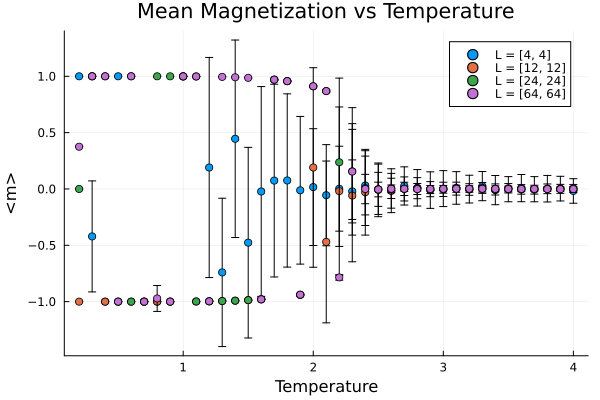

In [6]:
# Magnetization vs Temperature Plot
m_4  = []
m_12 = []
m_24 = []
m_64 = []
for T in T_list
    push!(m_4,data_4[1][T][1],data_4[1][T][2],T)
    push!(m_12,data_12[1][T][1],data_12[1][T][2],T)
    push!(m_24,data_24[1][T][1],data_24[1][T][2],T)
    push!(m_64,data_64[1][T][1],data_64[1][T][2],T)

end
m_4 = reshape(m_4,3,39)
m_4 = transpose(m_4)

m_12 = reshape(m_12,3,39)
m_12 = transpose(m_12)

m_24 = reshape(m_24,3,39)
m_24 = transpose(m_24)

m_64 = reshape(m_64,3,39)
m_64 = transpose(m_64)

mag_plot = plot(xlabel="Temperature",ylabel="<m>",title="Mean Magnetization vs Temperature")
for i in 1:length(L_list)
    L = L_list[i]
    if L == [4,4]
        scatter!(mag_plot,m_4[:,3],m_4[:,1],yerror=m_4[:,2],label="L = $L")
    elseif L == [12,12]
        scatter!(mag_plot,m_12[:,3],m_12[:,1],yerror=m_12[:,2],label="L = $L")
    elseif L == [24,24]
        scatter!(mag_plot,m_24[:,3],m_24[:,1],yerror=m_24[:,2],label="L = $L")
    elseif L == [64,64]
        scatter!(mag_plot,m_64[:,3],m_64[:,1],yerror=m_64[:,2],label="L = $L")
    end
end
display(mag_plot)


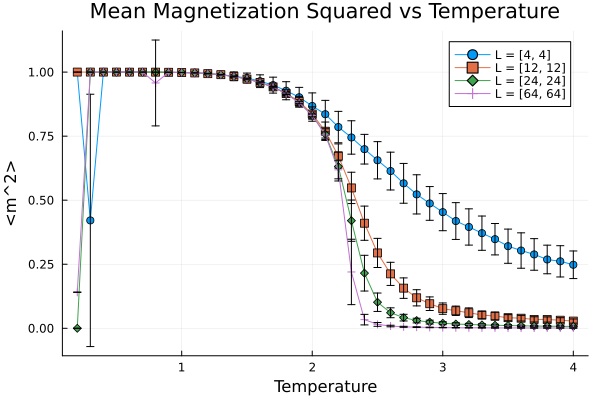

In [7]:
# Magnetization_Squared vs Temperature Plot
msq_4  = []
msq_12 = []
msq_24 = []
msq_64 = []
for T in T_list
    push!(msq_4,data_4[3][T][1],data_4[3][T][2],T)
    push!(msq_12,data_12[3][T][1],data_12[3][T][2],T)
    push!(msq_24,data_24[3][T][1],data_24[3][T][2],T)
    push!(msq_64,data_64[3][T][1],data_64[3][T][2],T)

end
msq_4 = reshape(msq_4,3,39)
msq_4 = transpose(msq_4)

msq_12 = reshape(msq_12,3,39)
msq_12 = transpose(msq_12)

msq_24 = reshape(msq_24,3,39)
msq_24 = transpose(msq_24)

msq_64 = reshape(msq_64,3,39)
msq_64 = transpose(msq_64)

msq_plot = plot(xlabel="Temperature",ylabel="<m^2>",title="Mean Magnetization Squared vs Temperature")
for i in 1:length(L_list)
    L = L_list[i]
    if L == [4,4]
        plot!(msq_plot,msq_4[:,3],msq_4[:,1],yerror=msq_4[:,2],label="L = $L",marker=:circle)
    elseif L == [12,12]
        plot!(msq_plot,msq_12[:,3],msq_12[:,1],yerror=msq_12[:,2],label="L = $L",marker=:square)
    elseif L == [24,24]
        plot!(msq_plot,msq_24[:,3],msq_24[:,1],yerror=msq_24[:,2],label="L = $L",marker=:diamond)
    elseif L == [64,64]
        plot!(msq_plot,msq_64[:,3],msq_64[:,1],yerror=msq_64[:,2],label="L = $L",marker=:cross)
    end
end
display(msq_plot)

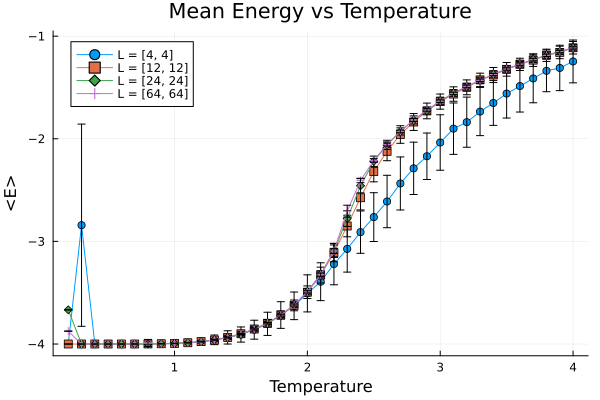

In [8]:
#Energy vs Temperature Plot
e_4  = []
e_12 = []
e_24 = []
e_64 = []
for T in T_list
    push!(e_4,data_4[2][T][1]/16,data_4[2][T][2]/16,T)
    push!(e_12,data_12[2][T][1]/144,data_12[2][T][2]/144,T)
    push!(e_24,data_24[2][T][1]/576,data_24[2][T][2]/576,T)
    push!(e_64,data_64[2][T][1]/4096,data_64[2][T][2]/4096,T)

end
e_4 = reshape(e_4,3,39)
e_4 = transpose(e_4)

e_12 = reshape(e_12,3,39)
e_12 = transpose(e_12)

e_24 = reshape(e_24,3,39)
e_24 = transpose(e_24)

e_64 = reshape(e_64,3,39)
e_64 = transpose(e_64)

e_plot = plot(xlabel="Temperature",ylabel="<E>",title="Mean Energy vs Temperature")
for i in 1:length(L_list)
    L = L_list[i]
    if L == [4,4]
        plot!(e_plot,e_4[:,3],e_4[:,1],yerror=e_4[:,2],label="L = $L",marker=:circle)
    elseif L == [12,12]
        plot!(e_plot,e_12[:,3],e_12[:,1],yerror=e_12[:,2],label="L = $L",marker=:square)
    elseif L == [24,24]
        plot!(e_plot,e_24[:,3],e_24[:,1],yerror=e_24[:,2],label="L = $L",marker=:diamond)
    elseif L == [64,64]
        plot!(e_plot,e_64[:,3],e_64[:,1],yerror=e_64[:,2],label="L = $L",marker=:cross)
    end
end
display(e_plot)

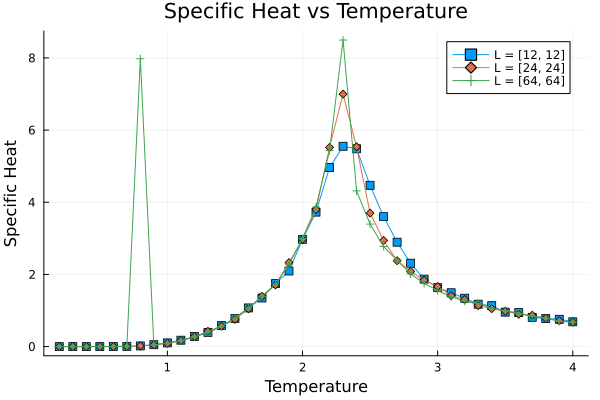

In [12]:
function energy_to_specific_heat(esq,e,T,N)
    c = (esq - e^2)/(T^2*N)
    return c
end


function get_specific_heat(data_L,N)
    c = []
    for T in T_list
        e = data_L[2][T][1]
        esq = data_L[5][T][1]
        cT = energy_to_specific_heat(esq,e,T,N)
        push!(c, cT)
    end
    return c
end

c_4 = get_specific_heat(data_4,16)
c_12 = get_specific_heat(data_12,144)
c_24 = get_specific_heat(data_24,576)
c_64 = get_specific_heat(data_64,4096)

c_plot = plot(xlabel="Temperature",ylabel="Specific Heat",title="Specific Heat vs Temperature")
for i in 1:length(L_list)
    L = L_list[i]
    if L == [4,4]
        #plot!(c_plot,T_list,c_4,label="L = $L",marker=:circle)
    elseif L == [12,12]
        plot!(c_plot,T_list,c_12,label="L = $L",marker=:square)
    elseif L == [24,24]
        plot!(c_plot,T_list,c_24,label="L = $L",marker=:diamond)
    elseif L == [64,64]
        plot!(c_plot,T_list,c_64,label="L = $L",marker=:cross)
    end
end
display(c_plot)

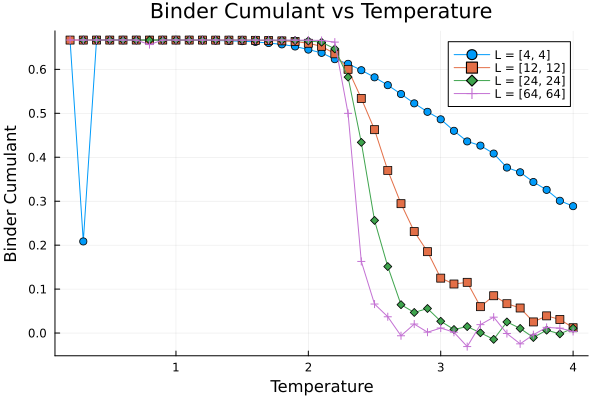

In [233]:
# Binder Cumulant vs Temperature Plot
function binder_cumulant(m,mqrt)
    U = 1 - mqrt/(3*m^2)
    return U
end

function get_binder_cumulant(data_L)
    U = []
    for T in T_list
        m = data_L[3][T][1]
        mqrt = data_L[4][T][1]
        U_T = binder_cumulant(m,mqrt)
        push!(U,U_T)
    end
    return U
end
U_4 = get_binder_cumulant(data_4)
U_12 = get_binder_cumulant(data_12)
U_24 = get_binder_cumulant(data_24)
U_64 = get_binder_cumulant(data_64)

U_plot = plot(xlabel="Temperature",ylabel="Binder Cumulant",title="Binder Cumulant vs Temperature")
for i in 1:length(L_list)
    L = L_list[i]
    if L == [4,4]
        plot!(U_plot,T_list,U_4,label="L = $L",marker=:circle)
    elseif L == [12,12]
        plot!(U_plot,T_list,U_12,label="L = $L",marker=:square)
    elseif L == [24,24]
        plot!(U_plot,T_list,U_24,label="L = $L",marker=:diamond)
    elseif L == [64,64]
        plot!(U_plot,T_list,U_64,label="L = $L",marker=:cross)
    end
end
display(U_plot)

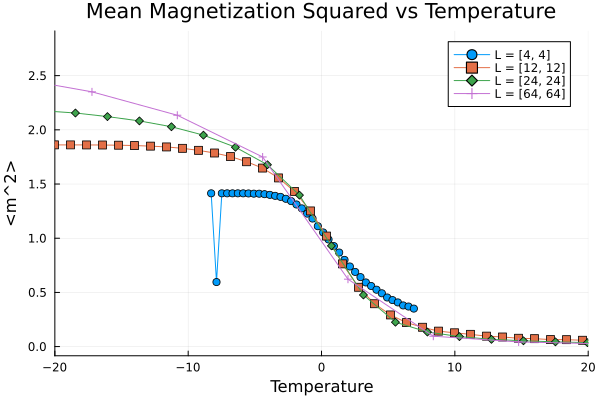

[-2.069, -1.969, -1.8690000000000002, -1.7690000000000001, -1.669, -1.5690000000000002, -1.469, -1.3690000000000002, -1.2690000000000001, -1.169, -1.0690000000000002, -0.9690000000000001, -0.8690000000000002, -0.7690000000000001, -0.669, -0.5690000000000002, -0.4690000000000001, -0.3690000000000002, -0.26900000000000013, -0.16900000000000004, -0.06899999999999995, 0.030999999999999694, 0.13099999999999978, 0.23099999999999987, 0.33099999999999996, 0.43100000000000005, 0.5309999999999997, 0.6309999999999998, 0.7309999999999999, 0.831, 0.931, 1.0309999999999997, 1.1309999999999998, 1.2309999999999999, 1.331, 1.431, 1.5309999999999997, 1.6309999999999998, 1.7309999999999999]


In [11]:
# Finite Size Scaling Analysis
β = 1/8
ν = 1
msq_plot = plot(xlabel="Temperature",ylabel="<m^2>",title="Mean Magnetization Squared vs Temperature")
T_array = (msq_12[:,3].-2.269)
for i in 1:length(L_list)
    L = L_list[i]
    N = L[1]
    if L == [4,4]
        plot!(msq_plot, T_array.*N^(1/ν),msq_4[:,1].*N^(2*β/ν),label="L = $L",marker=:circle)
    elseif L == [12,12]
        plot!(msq_plot, T_array.*N^(1/ν),msq_12[:,1].*N^(2*β/ν),label="L = $L",marker=:square)
    elseif L == [24,24]
        plot!(msq_plot, T_array.*N^(1/ν),msq_24[:,1].*N^(2*β/ν),label="L = $L",marker=:diamond)
    elseif L == [64,64]
        plot!(msq_plot, T_array.*N^(1/ν),msq_64[:,1].*N^(2*β/ν),label="L = $L",marker=:cross)
    end
end

xlims!(-20,20)
display(msq_plot)
println(msq_24[:,3].-2.269)

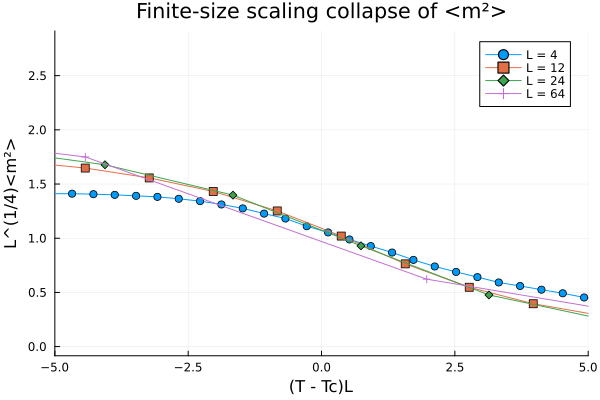

In [237]:
β = 1/8
ν = 1
Tc = 2.269185

msq_plot = plot(
    xlabel = "(T - Tc)L",
    ylabel = "L^(1/4)<m²>",
    title = "Finite-size scaling collapse of <m²>"
)

datasets = [
    (4,  msq_4,  :circle),
    (12, msq_12, :square),
    (24, msq_24, :diamond),
    (64, msq_64, :cross)
]

for (L, data, marker) in datasets
    T = data[:,3]
    m2 = data[:,1]

    x = (T .- Tc) .* L^(1/ν)
    y = m2 .* L^(2β/ν)

    plot!(msq_plot, x, y, label="L = $L", marker=marker)
end

xlims!(msq_plot, -5, 5)
display(msq_plot)